In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [2]:
df.drop(columns="CustomerID",inplace=True)

In [3]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [4]:
features = ["Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

X = df[features]

In [5]:
numeric_features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
categorical_features = ["Gender"]

In [6]:
numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

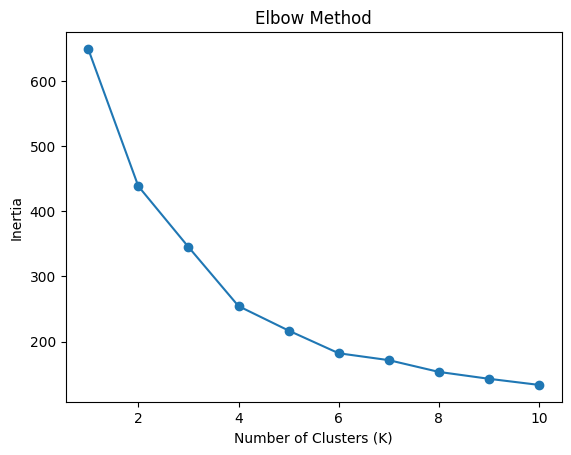

In [8]:
inertia = []
K_range = range(1, 11)
X_processed = preprocessor.fit_transform(X)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_processed)
    inertia.append(kmeans.inertia_)
# Plot elbow graph
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [13]:
# choose k=5
model = Pipeline([
    ("preprocessing", preprocessor),
    ("kmeans", KMeans(n_clusters=5, random_state=42))
])
model.fit(X)
clusters = model.predict(X)
df["Cluster"] = clusters

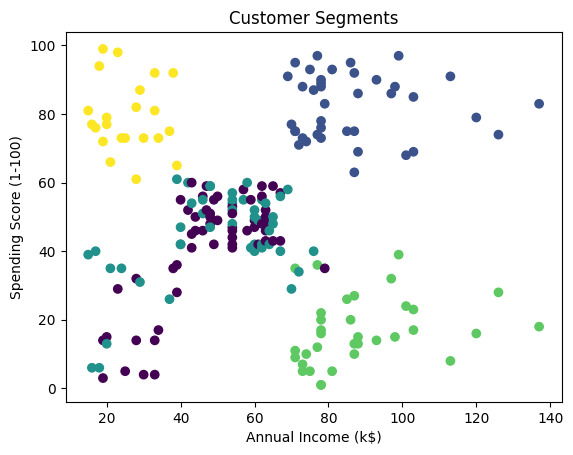

In [14]:
plt.figure()

plt.scatter(

    df["Annual Income (k$)"],

    df["Spending Score (1-100)"],

    c=df["Cluster"]

)

plt.xlabel("Annual Income (k$)")

plt.ylabel("Spending Score (1-100)")

plt.title("Customer Segments")

plt.show()

In [16]:
# prediction
new_data = pd.DataFrame({
    "Gender": ["Male"],
    "Age": [30],
    "Annual Income (k$)": [60],
    "Spending Score (1-100)": [70]
})
pred_cluster = model.predict(new_data)
print("New Customer Cluster:", pred_cluster)

New Customer Cluster: [2]
